# SPRINT 1: DATA EXPLORATION AND RESEARCH QUESTIONS

OBJETIVOS:

1. Cargar el dataset: código facilitado
2. Explorar el dataset: código facilitado
3. Normalizar la información: completar código
4. Plantear preguntas de investigación relevantes relacionadas con el aprendizaje no supervisado: completar texto
5. Reflexión final sobre técnicas de reducción de datos: completar texto





Autor: Adrián Robles Arques

In [2]:
# import some libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# seaborn is a layer on top of matplotlib which has additional visualizations -
# just importing it changes the look of the standard matplotlib plots.
# the current version also shows some warnings which we'll disable.
import seaborn as sns
sns.set(style="white", color_codes=True)
import warnings
warnings.filterwarnings("ignore")

# show plots inline
%matplotlib inline

## 1.- Load Data





In [3]:
# get data and show some records

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# load dataset into Pandas DataFrame
data = pd.read_csv(url, names=['sepal length','sepal width','petal length','petal width','target'])


#data = data.drop('Id', axis=1) # get rid of the Id column - don't need it
data.sample(5)

,sepal length,sepal width,petal length,petal width,target
108,6.7,2.5,5.8,1.8,Iris-virginica
77,6.7,3.0,5.0,1.7,Iris-versicolor
6,4.6,3.4,1.4,0.3,Iris-setosa
120,6.9,3.2,5.7,2.3,Iris-virginica
60,5.0,2.0,3.5,1.0,Iris-versicolor


## 2a.- Explore Data

In [7]:
# split data into features (X) and labels (y)
X = data[['sepal length','sepal width','petal length','petal width']]
y = data['target']

print("\n Caracteristicas \n")
print(X.sample(5))
print("\n Target \n")
print(y.sample(5))


 Caracteristicas 

     sepal length  sepal width  petal length  petal width
8             4.4          2.9           1.4          0.2
68            6.2          2.2           4.5          1.5
58            6.6          2.9           4.6          1.3
115           6.4          3.2           5.3          2.3
26            5.0          3.4           1.6          0.4

 Target 

51    Iris-versicolor
1         Iris-setosa
38        Iris-setosa
27        Iris-setosa
30        Iris-setosa
Name: target, dtype: object


## 2b.- Visualize Data


In [8]:
data["target"].value_counts()


target
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

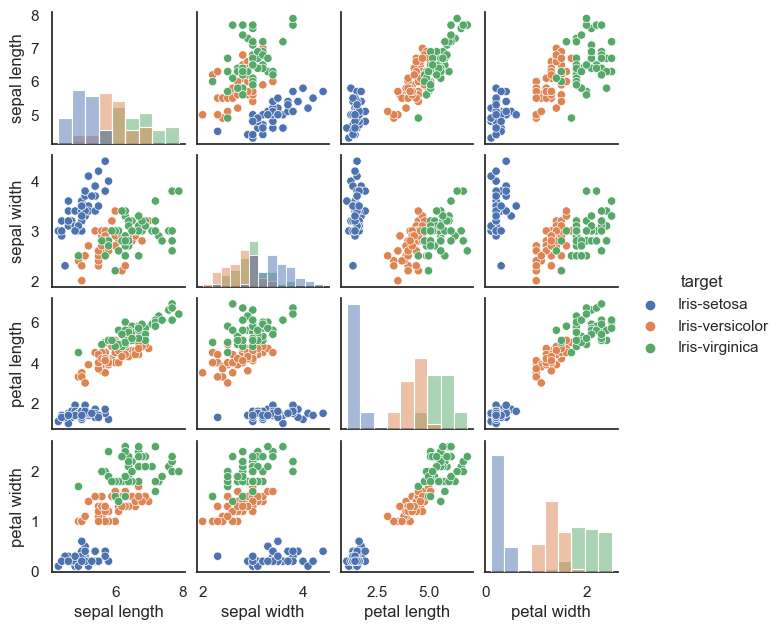

In [ ]:
sns.pairplot(data, hue="target", diag_kind="hist", size=1.6)


Versicolor y Virginica son muy similares, sera muy dificil generar un algoritmo de clustering que las pueda separar, pero vamos a intentarlo!!



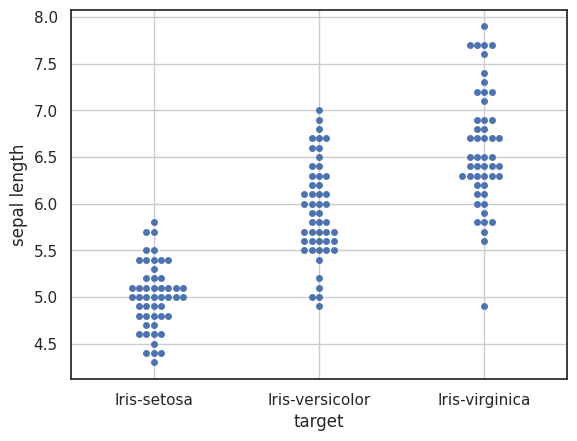

In [ ]:
sns.swarmplot(x="target", y="sepal length", data=data)
plt.grid()

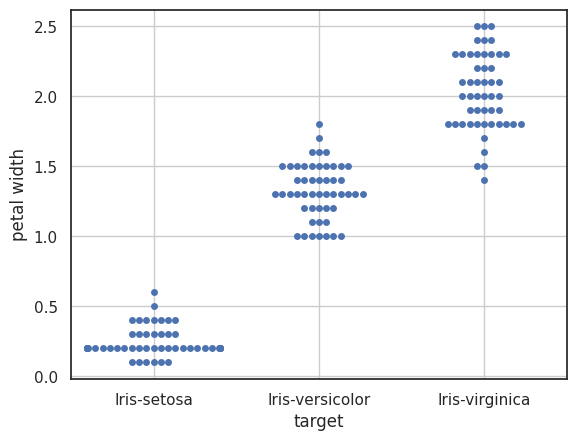

In [ ]:
sns.swarmplot(x="target", y="petal width", data=data)
plt.grid()

## 3.- Feature Scaling
Los datos estan desbalanceados por ejemplo Sepal Lenght es aproximadamente 4 veces mas grande que Petal Width, por lo tando recomiendo escalar los valores. de lo contrario, las características más grandes dominarán a las demás en la agrupación, etc.

In [35]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns = X.columns)

X_scaled.sample(5)

,sepal length,sepal width,petal length,petal width
46,-0.900681,1.726266,-1.227541,-1.312977
33,-0.416010,2.651878,-1.341272,-1.312977
69,-0.294842,-1.281972,0.080370,-0.129720
50,1.401508,0.337848,0.535296,0.264699
144,1.038005,0.569251,1.103953,1.710902


In [38]:
# Creamos el DataFrame con los datos reescalados
Data_scaled = pd.concat([X_scaled, y], axis=1)
Data_scaled

,sepal length,sepal width,petal length,petal width,target
0,-0.900681,1.032057,-1.341272,-1.312977,Iris-setosa
1,-1.143017,-0.124958,-1.341272,-1.312977,Iris-setosa
2,-1.385353,0.337848,-1.398138,-1.312977,Iris-setosa
3,-1.506521,0.106445,-1.284407,-1.312977,Iris-setosa
4,-1.021849,1.263460,-1.341272,-1.312977,Iris-setosa
...,...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956,Iris-virginica
146,0.553333,-1.281972,0.705893,0.922064,Iris-virginica
147,0.795669,-0.124958,0.819624,1.053537,Iris-virginica
148,0.432165,0.800654,0.933356,1.447956,Iris-virginica


## 4.- Research questions

--------------------------------------------------------------------
INCORPORA AQUI LAS PREGUNTAS DE INVESTIGACIÓN

--------------------------------------------------------------------

* ¿Qué relación hay entre longitud y anchura de pétalos y sépalos? (Asociación)
* ¿Existe alguna relación entre el tamaño de los sépalos y los pétalos? (Asociación)
* ¿Qué posibles conjuntos podemos agrupar en función de las características de los pétalos y los sépalos? (Agrupación)




## 5.- Reflexión final técnicas de reducción de dimensionalidad

---------------------------------------------------
INCORPORA AQUÍ TU REFLEXIÓN SOBRE ESTE PUNTO

----------------------------------------------------
Si analizamos los datos sin etiquetar tras el reescalado, vemos que algunas relaciones son claramente lineales, como el largo y ancho de los sépalos, u otras que aunque no sea tan claro, sí parecen tener cierta linealidad en su relación, como la longitud del pétalo y del sépalo. Otras, sin embargo, no parecen en absoluto lineales, como el ancho y largo del pétalo. 

Por tanto, para capturar estas relaciones, si pretendemos emplear una reducción de dimensionalidad, deberíamos emplear técnicas diferentes. Por ejemplo, para las relaciones lineales, PCA sería una buena opción, ya que permitiría agrupar dicha información en una menor cantidad de variables; mientras que para las no lineales, otros algoritmos no lineales, tales como t-SNE o UMAP, podrían ser más adecuados, o de lo contrario nos enfrentaríamos a una pérdida sustancial de información.

# SPRINT 2: CLUSTERING

OBJETIVOS:
1. Practicar método silueta
2. Practicar método del codo
3. Practicar modelo clustering k-means
4. Añadir conclusiones

Autor: Adrián Robles Arques

## 1.- Silhouette

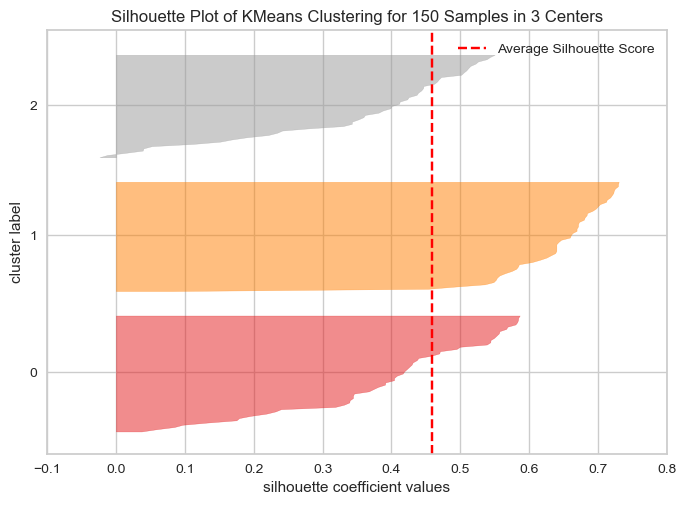

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 150 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [12]:
# Instantiate the clustering model and visualizer
#pip install yellowbrick

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

nclusters = 3
seed = 0

model = KMeans(n_clusters=nclusters
            , init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.show()    # Draw/show/show the data

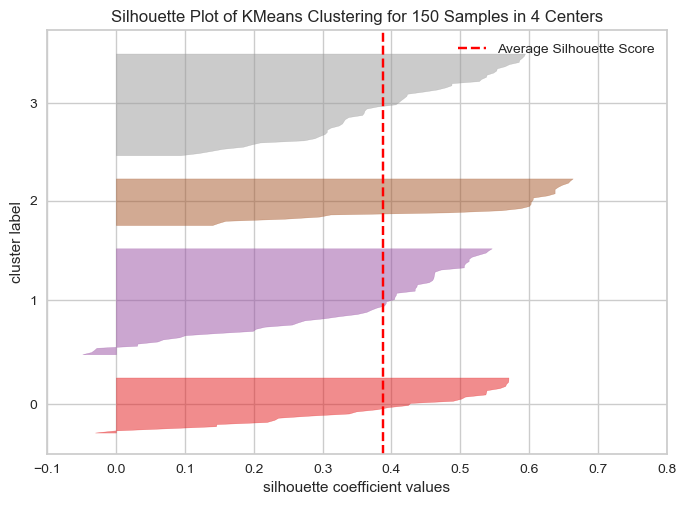

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 150 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [11]:
# Instantiate the clustering model and visualizer
#pip install yellowbrick


from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

nclusters = 4
seed = 0

model = KMeans(n_clusters=nclusters
            , init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_scaled)    # Fit the data to the visualizer
visualizer.show()    # Draw/show/show the data

## 2.- Elbow

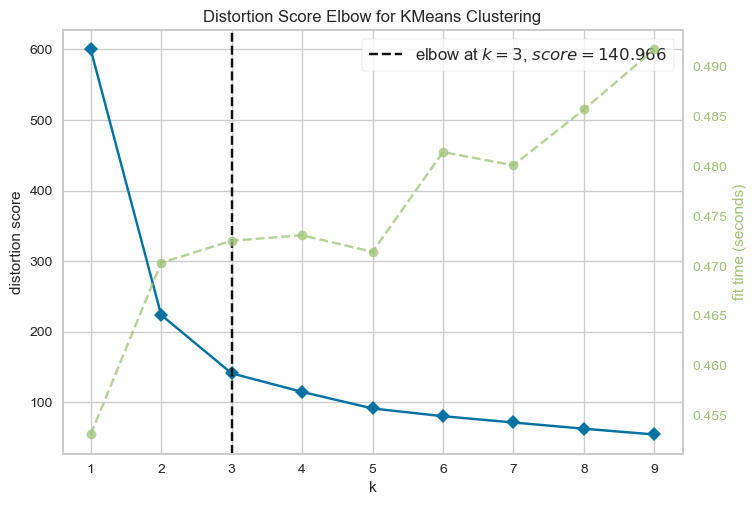

In [17]:
#from sklearn import datasets
from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model and visualizer

seed = 0

km = KMeans(init = 'k-means++'
            , max_iter=500
            , n_init=10
            , random_state=seed)


visualizer = KElbowVisualizer(km, k=(1,10))

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()    # Finalize and render the figure
k = visualizer.elbow_value_

## 3.- K-Means
Intente agrupar los datos en 4D y ver si puede reproducir los clústeres reales. Es decir, imagine que no tenemos las etiquetas de especies en estos datos y queremos dividir las flores en especies. podría establecer un número arbitrario de grupos e intentar dividirlos en grupos similares. Sabemos que hay 3 especies, así que encontremos 3 especies y veamos si las predicciones para cada punto coinciden con la etiqueta en y, por otro lado sabemos que por el metodo de las siluetas y elbow, la cantidad de clusters recomendada es 3

In [41]:
from sklearn.cluster import KMeans

nclusters = k
seed = 42

#DESARROLLE AQUI EL METODO DE KMeans utilizando la libreia KMeans.

km = KMeans( n_clusters = nclusters, random_state = seed, init='k-means++', n_init=10, max_iter=300)
km.fit(X_scaled)

# Predecir el clúster al que pertenece cada punto de datos
y_cluster_kmeans = km.predict(X_scaled)

print("\n Caracteristicas \n")
print(X_scaled)

print("\n\n\n Clusters \n")
print(y_cluster_kmeans)


 Caracteristicas 

     sepal length  sepal width  petal length  petal width
0       -0.900681     1.032057     -1.341272    -1.312977
1       -1.143017    -0.124958     -1.341272    -1.312977
2       -1.385353     0.337848     -1.398138    -1.312977
3       -1.506521     0.106445     -1.284407    -1.312977
4       -1.021849     1.263460     -1.341272    -1.312977
..            ...          ...           ...          ...
145      1.038005    -0.124958      0.819624     1.447956
146      0.553333    -1.281972      0.705893     0.922064
147      0.795669    -0.124958      0.819624     1.053537
148      0.432165     0.800654      0.933356     1.447956
149      0.068662    -0.124958      0.762759     0.790591

[150 rows x 4 columns]



 Clusters 

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0

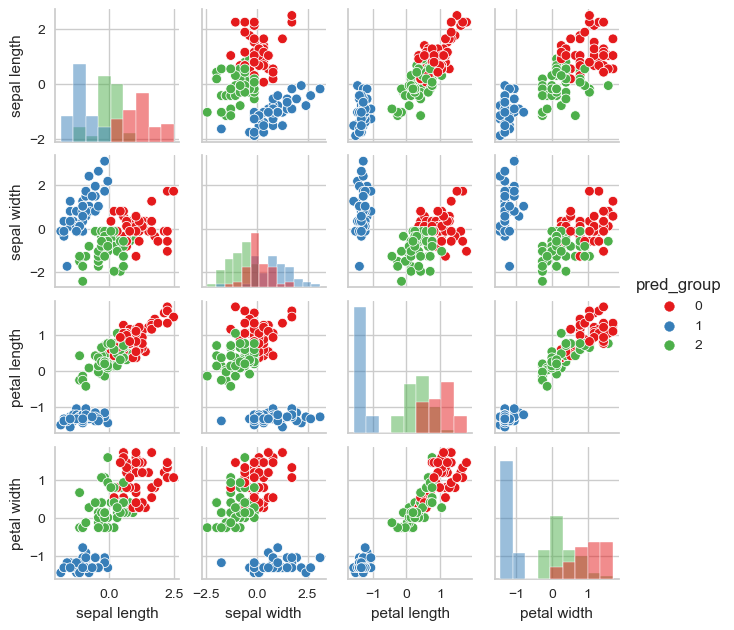

In [42]:
#Visualizamos los datos de nuestro modelo KMeans
pred_data = X_scaled.copy()
pred_data['pred_group'] = y_cluster_kmeans
sns.pairplot(pred_data, hue= 'pred_group', diag_kind="hist", size=1.6, palette= 'Set1')

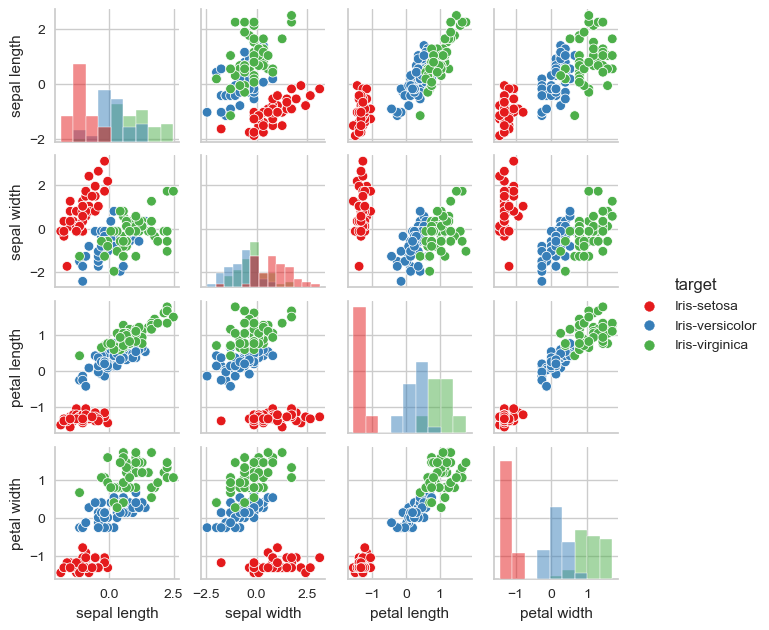

In [40]:
#Comparamos con los resultados originales reescalados
sns.pairplot(Data_scaled, hue= 'target', size= 1.6, palette= 'Set1', diag_kind="hist")

## 4.- Investigación
Una vez que hayas aplicado técnicas de clustering al conjunto de datos, ¿cómo podrías evaluar si los clusters obtenidos son realmente representativos y bien formados? Investiga y describe métricas que permitan medir la calidad de los clusters, como la distancia intra-cluster (cohesión) y la distancia inter-cluster (separación). ¿Qué valores de estas métricas indicarían un buen resultado y por qué?

--------------------------------------------------------------
Medir la calidad de un clúster

Una medida de calidad de un clustering es una función que recibe un clustering C
sobre (X,d) (donde d es una función de distancia sobre X) y devuelve un número real no negativo.

En este caso podríamos emplear dos tipos de medidas, las de validación interna, que emplean unicamente los datos incorporador en el propio conjunto de datos empleado para el proceso de clustering, o la validación externa, donde se cruzan los datos con otros conjuntos con los que poder generar un proceso de validación, como por ejemplo en este caso, los datos iniciales que incluyen la clasificación.

Como medidas internas, tenemos medidas de cohesión, como un potencial de estres que calcula el sumatorio de distancias al cuadrado de cada punto al centroide de su cluster. Esto también puede emplearse para generar una evaluación más general de la calidad de los clusters con el denominado índice de David Bouldin, que se calcula como un coeficiente entre la media de distancia intracluster y la distancia intercluster.

* Indice de Davies Bouldin (DBI): $\text{DBI} = \frac{1}{N} \sum_{i=1}^{N} \max_{j \neq i} \left( \frac{\text{C}(g_i) + \text{C}(c_j)}{\text{S}(g_i, g_j)} \right), g_i, g_j \subset S$ siendo $g_i$ y $g_j$ dos subgrupos cualesquiera y $N$ el número de grupos.

* Donde la cohesión del subgrupo o C($g_i$): $\text{C}(g_i) = \left( \frac{1}{n_i} \sum_{j = 1}^{n_i} |x_j - c_i|\right)$ siendo $c_i$ el centroide del subgrupo $g_i$ y $n_i$ el número de elementos del subgrupo.

* Y la separación entre dos subgrupos o S($g_i$, $g_j$): $\text{S}(g_i, g_j) = |c_i - c_j|$ siendo $c_i$ y $c_j$ los centroides de los subgrupos $g_i$ y $g_j$.

Cuanto más ajustado sea el clúster y más separados estén los clústeres, más bajo será este valor, por lo que los valores más próximos a 0 son mejores. Los clústeres que estén más separados y menos dispersos generarán una mejor puntuación. 

--------------------------------------------------------------

In [ ]:
# Implementamos el davies_bouldin_score para evaluar la calidad de los clusters obtenidos con KMeans
from sklearn.metrics import davies_bouldin_score

DBS = davies_bouldin_score(X_scaled, y_cluster_kmeans)
DBS

0.8354098493935598